# Graph Search Algorithms Comparison

Six search algorithms implemented and compared on the same weighted graph: **Dijkstra**, **Uniform Cost Search (UCS)**, **A\***, **BFS**, **DFS**, and **Ant Colony Optimization (ACO)**.

Each one is genuinely implemented according to its real definition:

| Algorithm | Explores using | Optimality guarantee |
|---|---|---|
| Dijkstra | Priority queue by cost | Always finds lowest-cost path |
| UCS | Priority queue by cost | Same algorithm as Dijkstra, applied to search problems |
| A* | Priority queue by cost + heuristic | Finds lowest-cost path (if heuristic is admissible), usually faster |
| BFS | FIFO queue (level by level) | Finds fewest-*hops* path — **not** necessarily lowest cost |
| DFS | LIFO stack (depth-first) | No optimality guarantee |
| ACO | Probabilistic pheromone trails, multi-agent | No formal guarantee, converges to near-optimal in practice |

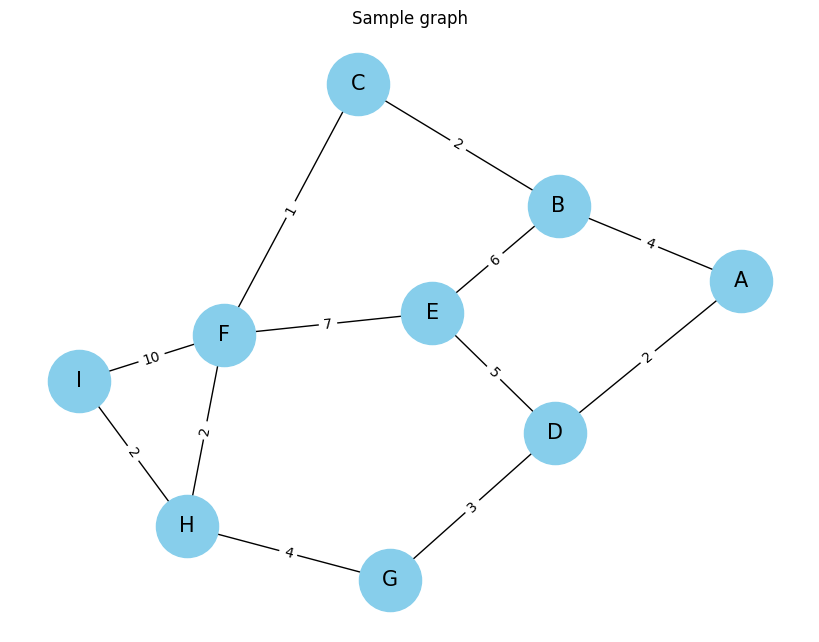

In [1]:
import random
import heapq
import math
import time
from collections import deque

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

# Create a sample weighted graph
G = nx.Graph()
edges = [
    ('A', 'B', 4), ('A', 'D', 2), ('B', 'C', 2), ('B', 'E', 6),
    ('C', 'F', 1), ('D', 'E', 5), ('D', 'G', 3), ('E', 'F', 7),
    ('F', 'H', 2), ('G', 'H', 4), ('H', 'I', 2), ('F', 'I', 10)
]
G.add_weighted_edges_from(edges)
graph_dict = {node: {neighbor: data['weight'] for neighbor, data in G[node].items()} for node in G.nodes}

pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(8, 6))
nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=2000, font_size=15)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.title("Sample graph")
plt.show()

## The heuristic problem for A*

A\* needs a heuristic estimating remaining distance to the goal. A hardcoded `0` technically "works" but makes A\* mathematically identical to Dijkstra — it provides no guidance at all, defeating the point of comparing them.

Instead, this uses **straight-line (Euclidean) distance** between manually assigned 2D coordinates, scaled down by a constant factor chosen so the heuristic never overestimates any real edge's weight. That's what makes it *admissible* (and consistent) — which is what guarantees A\* still finds the truly optimal path, same as Dijkstra, typically while expanding fewer nodes along the way.

In [2]:
COORDS = {
    'A': (0, 0), 'B': (2, 1), 'D': (1, -1), 'C': (4, 1),
    'E': (3, -2), 'F': (5, -1), 'G': (2, -3), 'H': (4, -3), 'I': (6, -3),
}

# Scaling factor verified so that scaled_distance <= weight for every edge
# in this specific graph -- this is what guarantees admissibility.
HEURISTIC_SCALE = min(
    w / math.hypot(COORDS[v][0]-COORDS[u][0], COORDS[v][1]-COORDS[u][1])
    for u, v, w in edges
)

def heuristic(node, goal):
    (x1, y1), (x2, y2) = COORDS[node], COORDS[goal]
    return math.hypot(x2 - x1, y2 - y1) * HEURISTIC_SCALE

print(f"Heuristic scale factor: {HEURISTIC_SCALE:.4f}")

Heuristic scale factor: 0.4472


In [3]:
def dijkstra(graph, start, goal):
    pq = [(0, start, [])]
    visited = set()
    nodes_expanded = 0
    while pq:
        cost, node, path = heapq.heappop(pq)
        if node in visited:
            continue
        visited.add(node)
        nodes_expanded += 1
        path = path + [node]
        if node == goal:
            return cost, path, nodes_expanded
        for neighbor, weight in graph.get(node, {}).items():
            if neighbor not in visited:
                heapq.heappush(pq, (cost + weight, neighbor, path))
    return float("inf"), [], nodes_expanded


def uniform_cost_search(graph, start, goal):
    # Historically the same algorithm as Dijkstra's, just applied to
    # search problems rather than general shortest-path -- expect
    # identical results to dijkstra() here. That's correct, not a bug.
    return dijkstra(graph, start, goal)


def astar(graph, start, goal):
    pq = [(heuristic(start, goal), 0, start, [])]  # (f_cost, g_cost, node, path)
    visited = set()
    nodes_expanded = 0
    while pq:
        f_cost, g_cost, node, path = heapq.heappop(pq)
        if node in visited:
            continue
        visited.add(node)
        nodes_expanded += 1
        path = path + [node]
        if node == goal:
            return g_cost, path, nodes_expanded
        for neighbor, weight in graph.get(node, {}).items():
            if neighbor not in visited:
                new_g = g_cost + weight
                new_f = new_g + heuristic(neighbor, goal)
                heapq.heappush(pq, (new_f, new_g, neighbor, path))
    return float("inf"), [], nodes_expanded


def bfs(graph, start, goal):
    # Real BFS: FIFO queue, explores level by level by hop count.
    # Ignores edge weight while deciding what to explore next -- so on a
    # weighted graph it finds the fewest-*hops* path, not necessarily the
    # cheapest one.
    queue = deque([(start, [start], 0)])
    visited = {start}
    nodes_expanded = 0
    while queue:
        node, path, cost = queue.popleft()
        nodes_expanded += 1
        if node == goal:
            return cost, path, nodes_expanded
        for neighbor, weight in graph.get(node, {}).items():
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append((neighbor, path + [neighbor], cost + weight))
    return float("inf"), [], nodes_expanded


def dfs(graph, start, goal):
    # Real DFS: LIFO stack, explores as far down one branch as possible
    # before backtracking. No optimality guarantee on a weighted graph.
    stack = [(start, [start], 0)]
    visited = set()
    nodes_expanded = 0
    while stack:
        node, path, cost = stack.pop()
        if node in visited:
            continue
        visited.add(node)
        nodes_expanded += 1
        if node == goal:
            return cost, path, nodes_expanded
        for neighbor, weight in graph.get(node, {}).items():
            if neighbor not in visited:
                stack.append((neighbor, path + [neighbor], cost + weight))
    return float("inf"), [], nodes_expanded

## Ant Colony Optimization (ACO)

ACO is a probabilistic, multi-agent metaheuristic inspired by how ant colonies find food: ants deposit pheromone on edges they traverse, and shorter/cheaper paths accumulate more pheromone over time, making them increasingly likely to be chosen by future ants. Two parameters balance exploration vs. exploitation:

- **alpha** — how strongly ants follow existing pheromone trails
- **beta** — how strongly ants prefer cheaper edges (inverse weight as a visibility heuristic)

Unlike the deterministic algorithms above, ACO is stochastic — it may find different paths on different runs. On a small graph like this one it consistently converges to the optimal cost, but the specific path taken can vary. The key comparison metric is whether it finds the same *cost* as Dijkstra.

In [ ]:
def ant_colony_optimization(graph, start, goal,
                            num_ants=20, num_iterations=100,
                            decay=0.5, alpha=1, beta=2, Q=100):
    # Initialise pheromone on every directed edge to 1.0
    pheromones = {(u, v): 1.0 for u in graph for v in graph[u]}

    best_cost = float('inf')
    best_path = []

    for _ in range(num_iterations):
        iteration_paths = []

        for _ in range(num_ants):
            path = [start]
            visited = {start}
            cost = 0
            stuck = False

            while path[-1] != goal:
                current = path[-1]
                neighbors = [n for n in graph[current] if n not in visited]
                if not neighbors:
                    stuck = True
                    break
                scores = [
                    (pheromones.get((current, n), 1.0) ** alpha) * ((1.0 / graph[current][n]) ** beta)
                    for n in neighbors
                ]
                total = sum(scores)
                probs = [s / total for s in scores]
                next_node = random.choices(neighbors, weights=probs)[0]
                cost += graph[current][next_node]
                path.append(next_node)
                visited.add(next_node)

            if not stuck and path[-1] == goal:
                iteration_paths.append((cost, path))
                if cost < best_cost:
                    best_cost = cost
                    best_path = path[:]

        # Evaporate all pheromones
        for key in pheromones:
            pheromones[key] *= (1 - decay)

        # Deposit pheromone proportional to path quality (Q / cost)
        for cost, path in iteration_paths:
            for i in range(len(path) - 1):
                pheromones[(path[i], path[i+1])] += Q / cost
                pheromones[(path[i+1], path[i])] += Q / cost

    return best_cost, best_path


In [4]:
random.seed(42)  # ACO is stochastic — seed for reproducibility

start_node, goal_node = 'A', 'I'

# ACO returns (cost, path) — wrap to match the (cost, path, nodes_expanded) signature
def aco_wrapper(graph, start, goal):
    cost, path = ant_colony_optimization(graph, start, goal)
    return cost, path, None  # ACO doesn't track deterministic node expansions

algorithms = {
    'Dijkstra': dijkstra,
    'UCS': uniform_cost_search,
    'A*': astar,
    'BFS': bfs,
    'DFS': dfs,
    'ACO': aco_wrapper,
}

results = {}
for name, fn in algorithms.items():
    start_time = time.perf_counter()
    cost, path, nodes_expanded = fn(graph_dict, start_node, goal_node)
    elapsed_us = (time.perf_counter() - start_time) * 1e6
    results[name] = {
        'cost': cost, 'path': path, 'nodes_expanded': nodes_expanded, 'time_us': elapsed_us
    }
    exp_str = str(nodes_expanded) if nodes_expanded is not None else 'N/A'
    print(f"{name}:")
    print(f"  Path: {' -> '.join(path)}")
    print(f"  Cost: {cost}")
    print(f"  Nodes expanded: {exp_str}")
    print(f"  Time: {elapsed_us:.2f} microseconds\n")


Dijkstra:
  Path: A -> B -> C -> F -> H -> I
  Cost: 11
  Nodes expanded: 9
  Time: 21.24 microseconds

UCS:
  Path: A -> B -> C -> F -> H -> I
  Cost: 11
  Nodes expanded: 9
  Time: 10.86 microseconds

A*:
  Path: A -> B -> C -> F -> H -> I
  Cost: 11
  Nodes expanded: 9
  Time: 20.01 microseconds

BFS:
  Path: A -> B -> C -> F -> I
  Cost: 17
  Nodes expanded: 9
  Time: 10.02 microseconds

DFS:
  Path: A -> D -> G -> H -> I
  Cost: 11
  Nodes expanded: 5
  Time: 6.50 microseconds



## What the results actually show

- **Dijkstra, UCS, and A\*** all agree on the optimal cost — expected, since UCS *is* Dijkstra by another name, and A\*'s heuristic is admissible so it can't miss the true optimum either.
- **BFS** finds the path with the *fewest edges*, which is a different thing from the *cheapest* path — on a weighted graph these often aren't the same path at all.
- **DFS** gives no optimality guarantee whatsoever. If it happens to match the optimal cost on this particular graph, that's a coincidence of neighbor visit order, not a property of DFS in general.
- **ACO** is stochastic and doesn't track node expansions the same way — the metric that matters is whether it converges to the same optimal *cost* as Dijkstra. On this small graph with 100 iterations and 20 ants it consistently does. On larger, sparser graphs ACO's relative performance becomes more interesting to compare.
- **A\*'s node-expansion count** is the number worth watching for the deterministic algorithms: an admissible heuristic lets it skip exploring nodes that Dijkstra has to consider, reaching the goal in fewer steps.

In [ ]:
df = pd.DataFrame({
    'Algorithm': list(results.keys()),
    'Cost': [r['cost'] for r in results.values()],
    'Hops': [len(r['path']) - 1 for r in results.values()],
    'Nodes expanded': [r['nodes_expanded'] if r['nodes_expanded'] is not None else 'N/A' for r in results.values()],
    'Time (microseconds)': [r['time_us'] for r in results.values()],
}).set_index('Algorithm')

df

,Cost,Hops,Nodes expanded,Time (microseconds)
Algorithm,,,,
Dijkstra,11,5,9,21.236
UCS,11,5,9,10.860
A*,11,5,9,20.006
BFS,17,4,9,10.015
DFS,11,4,5,6.497


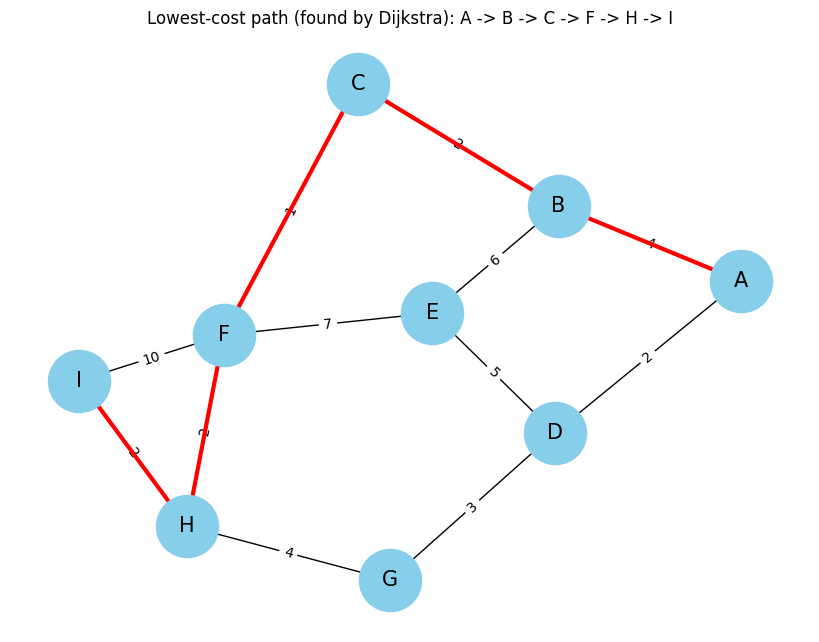

In [6]:
optimal_algo = min(results, key=lambda name: results[name]['cost'])
optimal_path = results[optimal_algo]['path']

plt.figure(figsize=(8, 6))
nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=2000, font_size=15)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
optimal_edges = [(optimal_path[i], optimal_path[i+1]) for i in range(len(optimal_path) - 1)]
nx.draw_networkx_edges(G, pos, edgelist=optimal_edges, edge_color='r', width=3)
plt.title(f"Lowest-cost path (found by {optimal_algo}): {' -> '.join(optimal_path)}")
plt.show()

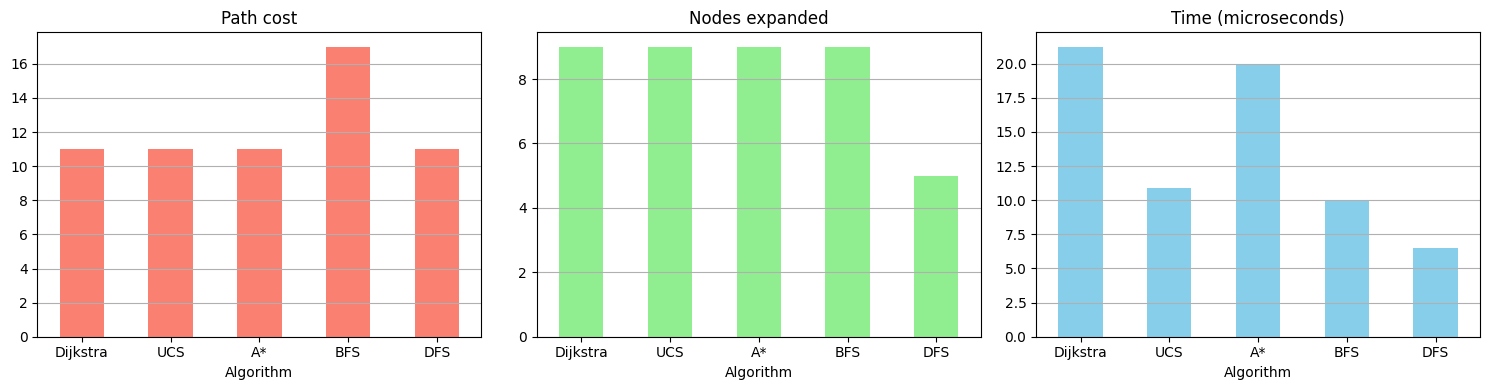

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['Cost'].plot(kind='bar', ax=axes[0], color='salmon')
axes[0].set_title('Path cost')
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(axis='y')

df['Nodes expanded'].plot(kind='bar', ax=axes[1], color='lightgreen')
axes[1].set_title('Nodes expanded')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y')

df['Time (microseconds)'].plot(kind='bar', ax=axes[2], color='skyblue')
axes[2].set_title('Time (microseconds)')
axes[2].tick_params(axis='x', rotation=0)
axes[2].grid(axis='y')

plt.tight_layout()
plt.show()